In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [2]:
pd.set_option("display.max_columns", None)

In [3]:
import warnings
warnings.filterwarnings("ignore")

#### data processing

In [4]:
data_path = "../data/"
output_path = "../output/"

In [5]:
data = pd.read_csv(data_path + "diabetes_130_full.csv", low_memory = False)

In [6]:
### Assign relevant item mapping to id from csv

IDs_mapping = pd.read_csv(data_path + "IDS_mapping.csv")

admission_id_mapping = IDs_mapping.iloc[:8, :]
admission_id_mapping['admission_type_id'] = admission_id_mapping['admission_type_id'].astype(int)
admission_id_mapping = admission_id_mapping.set_index('admission_type_id')['description'].to_dict()

discharge_id_mapping = IDs_mapping.iloc[10:40, :]
discharge_id_mapping['admission_type_id'] = discharge_id_mapping['admission_type_id'].astype(int)
discharge_id_mapping = discharge_id_mapping.set_index('admission_type_id')['description'].to_dict()

admission_source_id_mapping = IDs_mapping.iloc[42:, :]
admission_source_id_mapping['admission_type_id'] = admission_source_id_mapping['admission_type_id'].astype(int)
admission_source_id_mapping = admission_source_id_mapping.set_index('admission_type_id')['description'].to_dict()

data['admission_type_id'] = data['admission_type_id'].map(admission_id_mapping)
data['discharge_disposition_id'] = data['discharge_disposition_id'].map(discharge_id_mapping)
data['admission_source_id'] = data['admission_source_id'].map(admission_source_id_mapping)

In [7]:
data.drop(columns = ['Unnamed: 0'], axis = 1, inplace = True)

In [8]:
### drop repeated encounters, only keep the first. 

data.sort_values(by = ['encounter_id'], inplace = True)
data = data.drop_duplicates(subset='patient_nbr', keep='first')      

In [9]:
data = data[data['gender'].isin(['Female', 'Male'])]  # drop 3 rows, small missing

In [10]:
data.shape

(71515, 50)

#### start

In [11]:
df = data.copy()

##### drop factors

In [12]:
### drop weight due to 96% missing

df.drop(columns = ['weight'], axis = 1, inplace = True)

In [13]:
### these factors do not have qualitative / inherent meaning

df.drop(columns = ['admission_source_id', 'payer_code', 'medical_specialty','encounter_id', 'patient_nbr'], 
        axis = 1, 
        inplace = True)

In [14]:
mapping = {'NO': 0, '>30': 0, '<30': 1}
df['readmitted_binary'] = df['readmitted'].map(mapping)

### Single Factor Analysis (WoE and IV)

##### Categorical Variables

In [15]:
categorical_var = ['race', 'gender', 'age', 
                   'change', 'diabetesMed', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin', 'metformin',
                   'max_glu_serum', 'A1Cresult',
                   'readmitted_binary'
                  ]

In [16]:
def woe_discrete(categorical_var):
    
    WoE_results = pd.DataFrame()

    WoE_results[categorical_var] = df[categorical_var].copy()
    WoE_results['Bad'] = df['readmitted_binary']

    WoE_results[categorical_var] = WoE_results[categorical_var].fillna('Missing')

    Count = WoE_results.groupby([categorical_var]).count().reset_index()
    Mean = WoE_results.groupby([categorical_var]).mean().reset_index()

    df1 = pd.concat([Count, Mean], axis = 1)
    df1 = df1.iloc[:,[0,1,3]]

    df1.columns = [categorical_var, 'n_obs', 'prop_bad']

    df1['prop_good'] = 1 - df1['prop_bad']

    df1['n_bad'] = df1['prop_bad'] * df1['n_obs']
    df1['n_good'] = df1['prop_good'] * df1['n_obs']

    df1['prop_n_bad'] = df1['n_bad'] / df1['n_bad'].sum()
    df1['prop_n_good'] = df1['n_good'] / df1['n_good'].sum()

    df1['WoE'] = np.log((df1['prop_n_good'] + 1e-10) / (df1['prop_n_bad'] + + 1e-10))

    df1['%Good - %Bad'] = df1['prop_n_good'] - df1['prop_n_bad'] 

    df1['IV'] = df1['WoE'] * df1['%Good - %Bad']

    df1.IV = df1.IV.sum()

    df1['prop_total'] = df1['n_obs'] / df1['n_obs'].sum()
    
    df1.sort_values(by=categorical_var, inplace = True)

    return df1

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()                                #make sns the default style compared to matplotlib

def plot_by_woe(df, rotation_of_x_axis_labels = 0):
    x = np.array(df.iloc[:, 0].apply(str))               #matplotlib works better with numpy and scipy
    y = df['WoE']
    plt.figure(figsize=(18, 6))
    plt.plot(x, y, marker = 'o', linestyle = '--', color = 'k')
    plt.xlabel(df.columns[0])
    plt.ylabel('Weight of Evidence')
    plt.title(str('Weight of Evidence by ' + df.columns[0]))
    plt.xticks(rotation = rotation_of_x_axis_labels)

#looks ok

In [18]:
iv_dict = {}

for var in categorical_var:
    result_df = woe_discrete(var)
    iv_value = result_df['IV'].iloc[0] 
    iv_dict[var] = iv_value

iv_dict = dict(sorted(iv_dict.items(), key=lambda x: x[1], reverse=True))

for k, v in iv_dict.items():
    print(f"{k}: {v:.4f}")

readmitted_binary: 46.0517
age: 0.0317
diabetesMed: 0.0110
insulin: 0.0083
race: 0.0033
change: 0.0032
glipizide: 0.0024
metformin: 0.0020
max_glu_serum: 0.0010
A1Cresult: 0.0010
glimepiride: 0.0006
glyburide: 0.0005
pioglitazone: 0.0005
rosiglitazone: 0.0003
gender: 0.0001


### Age

In [19]:
woe_discrete('age')

,age,n_obs,prop_bad,prop_good,n_bad,n_good,prop_n_bad,prop_n_good,WoE,%Good - %Bad,IV,prop_total
0,[0-10),154,0.019481,0.980519,3.0,151.0,0.000477,0.002315,1.580308,0.001838,0.031658,0.002153
1,[10-20),535,0.048598,0.951402,26.0,509.0,0.004132,0.007804,0.635993,0.003673,0.031658,0.007481
2,[20-30),1127,0.073647,0.926353,83.0,1044.0,0.013189,0.016007,0.193615,0.002818,0.031658,0.015759
3,[30-40),2699,0.069655,0.930345,188.0,2511.0,0.029874,0.038499,0.253635,0.008625,0.031658,0.037740
4,[40-50),6878,0.073713,0.926287,507.0,6371.0,0.080566,0.097682,0.192642,0.017116,0.031658,0.096176
5,[50-60),12466,0.070512,0.929488,879.0,11587.0,0.139679,0.177655,0.240495,0.037976,0.031658,0.174313
6,[60-70),15959,0.088602,0.911398,1414.0,14545.0,0.224694,0.223008,-0.007534,-0.001687,0.031658,0.223156
7,[70-80),18208,0.100176,0.899824,1824.0,16384.0,0.289846,0.251204,-0.143086,-0.038642,0.031658,0.254604
8,[80-90),11589,0.103633,0.896367,1201.0,10388.0,0.190847,0.159271,-0.180862,-0.031576,0.031658,0.162050
9,[90-100),1900,0.088421,0.911579,168.0,1732.0,0.026696,0.026555,-0.005291,-0.000141,0.031658,0.026568


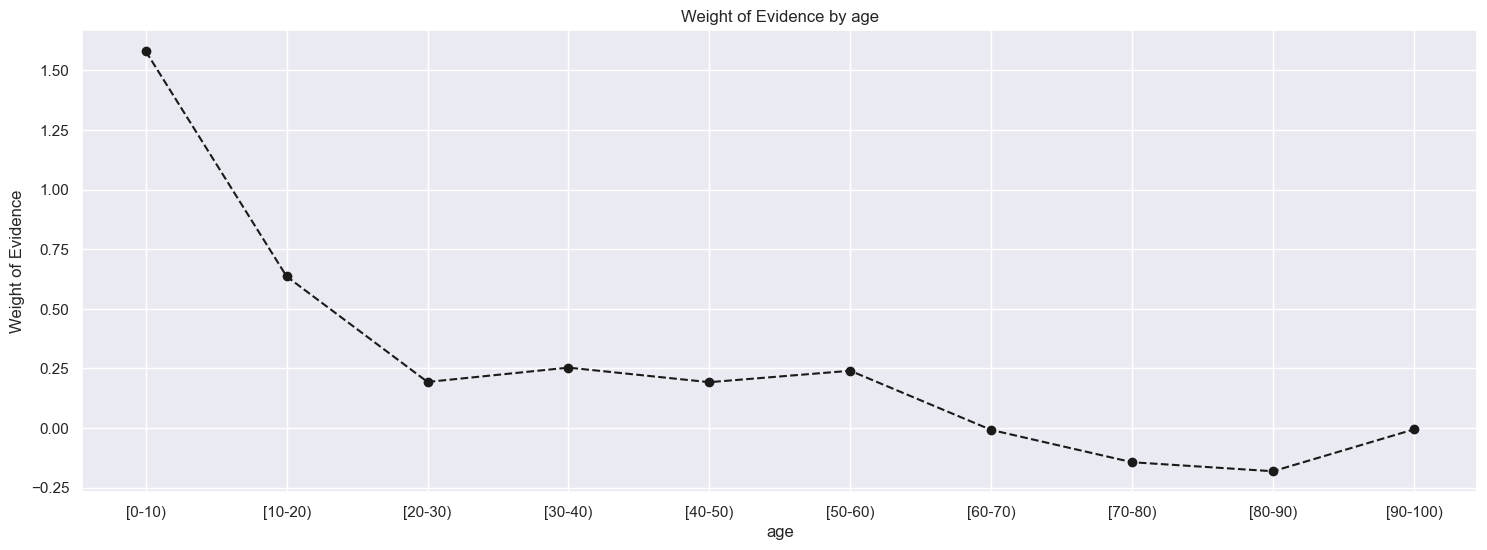

In [20]:
plot_by_woe(woe_discrete('age'))

In [21]:
df['age_coarse'] = df['age'].replace({
    '[0-10)':  '[0-20)',
    '[10-20)': '[0-20)',
    '[20-30)': '[20-40)',
    '[30-40)': '[20-40)',
    '[70-80)': '[70-100)',
    '[80-90)': '[70-100)',
    '[90-100)': '[70-100)'
})

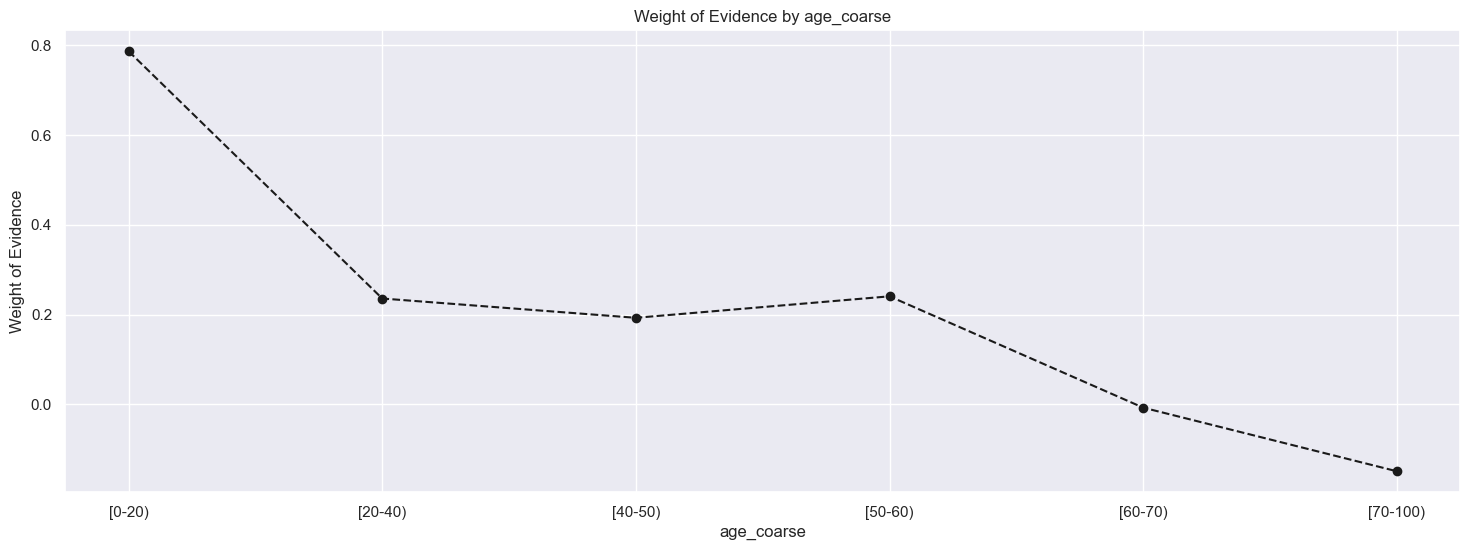

In [22]:
plot_by_woe(woe_discrete('age_coarse'))

In [23]:
woe_discrete('age_coarse')

,age_coarse,n_obs,prop_bad,prop_good,n_bad,n_good,prop_n_bad,prop_n_good,WoE,%Good - %Bad,IV,prop_total
0,[0-20),689,0.042090,0.957910,29.0,660.0,0.004608,0.010119,0.786585,0.005511,0.029977,0.009634
1,[20-40),3826,0.070831,0.929169,271.0,3555.0,0.043064,0.054506,0.235633,0.011442,0.029977,0.053499
2,[40-50),6878,0.073713,0.926287,507.0,6371.0,0.080566,0.097682,0.192642,0.017116,0.029977,0.096176
3,[50-60),12466,0.070512,0.929488,879.0,11587.0,0.139679,0.177655,0.240495,0.037976,0.029977,0.174313
4,[60-70),15959,0.088602,0.911398,1414.0,14545.0,0.224694,0.223008,-0.007534,-0.001687,0.029977,0.223156
5,[70-100),31697,0.100735,0.899265,3193.0,28504.0,0.507389,0.437030,-0.149275,-0.070359,0.029977,0.443222


##### Numerical Variables

In [24]:
numerical_features = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient',
                      'number_emergency', 'number_inpatient', 'number_diagnoses']

In [25]:
iv_dict = {}

for var in numerical_features:
    result_df = woe_discrete(var)
    iv_value = result_df['IV'].iloc[0] 
    iv_dict[var] = iv_value

iv_dict = dict(sorted(iv_dict.items(), key=lambda x: x[1], reverse=True))

for k, v in iv_dict.items():
    print(f"{k}: {v:.4f}")

number_inpatient: 0.0887
num_medications: 0.0563
time_in_hospital: 0.0450
num_lab_procedures: 0.0401
number_diagnoses: 0.0260
number_emergency: 0.0202
number_outpatient: 0.0168
num_procedures: 0.0022


### Number of inpatient

In [26]:
def bin_number_inpatient(x):
    if x == 0:
        return '0'
    elif x == 1:
        return '1'
    elif x == 2:
        return '2'
    elif 3 <= x <= 5:
        return '3-5'
    else:
        return '6+'

df['number_inpatient_coarse'] = df['number_inpatient'].apply(bin_number_inpatient)

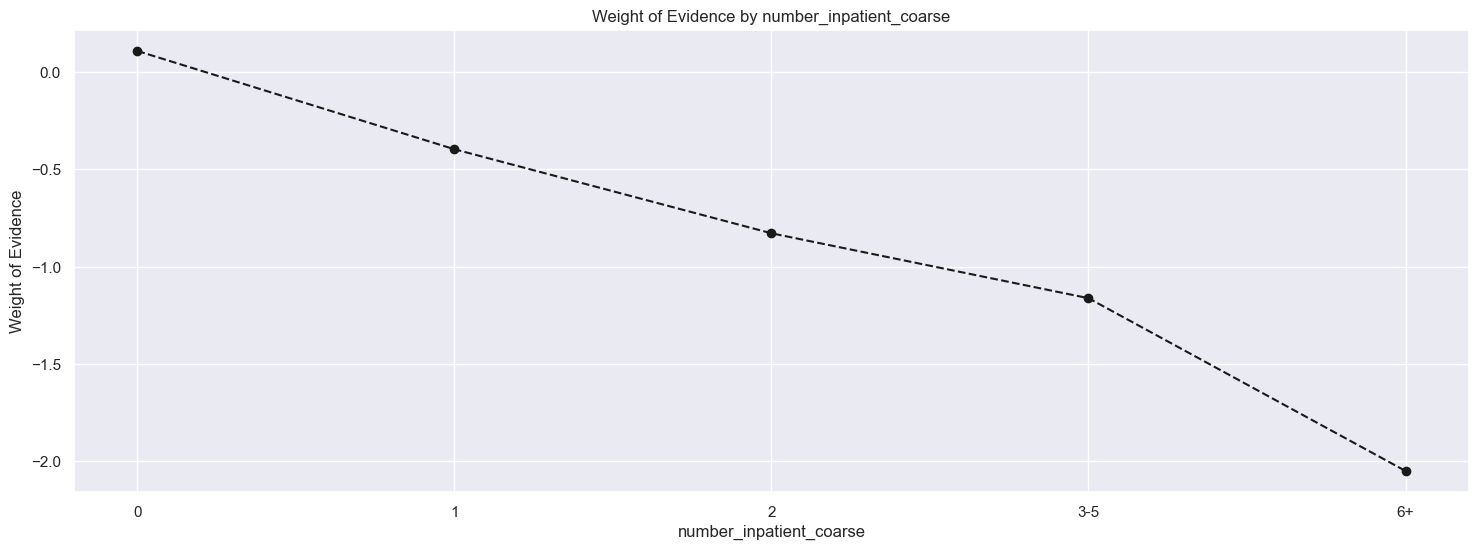

In [27]:
plot_by_woe(woe_discrete('number_inpatient_coarse'))

In [28]:
woe_discrete('number_inpatient_coarse')

,number_inpatient_coarse,n_obs,prop_bad,prop_good,n_bad,n_good,prop_n_bad,prop_n_good,WoE,%Good - %Bad,IV,prop_total
0,0,63074,0.079668,0.920332,5025.0,58049.0,0.798506,0.890022,0.108503,0.091515,0.083677,0.881969
1,1,5962,0.125461,0.874539,748.0,5214.0,0.118862,0.079942,-0.396659,-0.038920,0.083677,0.083367
2,2,1547,0.180995,0.819005,280.0,1267.0,0.044494,0.019426,-0.828741,-0.025068,0.083677,0.021632
3,3-5,827,0.235792,0.764208,195.0,632.0,0.030987,0.009690,-1.162469,-0.021297,0.083677,0.011564
4,6+,105,0.428571,0.571429,45.0,60.0,0.007151,0.000920,-2.050677,-0.006231,0.083677,0.001468


### Number of Medications

In [29]:
woe_discrete('num_medications')

,num_medications,n_obs,prop_bad,prop_good,n_bad,n_good,prop_n_bad,prop_n_good,WoE,%Good - %Bad,IV,prop_total
0,1,216,0.041667,0.958333,9.0,207.0,0.001430,0.003174,0.797135,0.001744,0.056345,0.003020
1,2,399,0.070175,0.929825,28.0,371.0,0.004449,0.005688,0.245639,0.001239,0.056345,0.005579
2,3,727,0.053645,0.946355,39.0,688.0,0.006197,0.010549,0.531868,0.004351,0.056345,0.010166
3,4,1169,0.057314,0.942686,67.0,1102.0,0.010647,0.016896,0.461830,0.006249,0.056345,0.016346
4,5,1631,0.058860,0.941140,96.0,1535.0,0.015255,0.023535,0.433579,0.008280,0.056345,0.022806
...,...,...,...,...,...,...,...,...,...,...,...,...
70,72,2,1.000000,0.000000,2.0,0.0,0.000318,0.000000,-14.971805,-0.000318,0.056345,0.000028
71,74,1,0.000000,1.000000,0.0,1.0,0.000000,0.000015,11.940305,0.000015,0.056345,0.000014
72,75,2,0.000000,1.000000,0.0,2.0,0.000000,0.000031,12.633449,0.000031,0.056345,0.000028
73,79,1,0.000000,1.000000,0.0,1.0,0.000000,0.000015,11.940305,0.000015,0.056345,0.000014


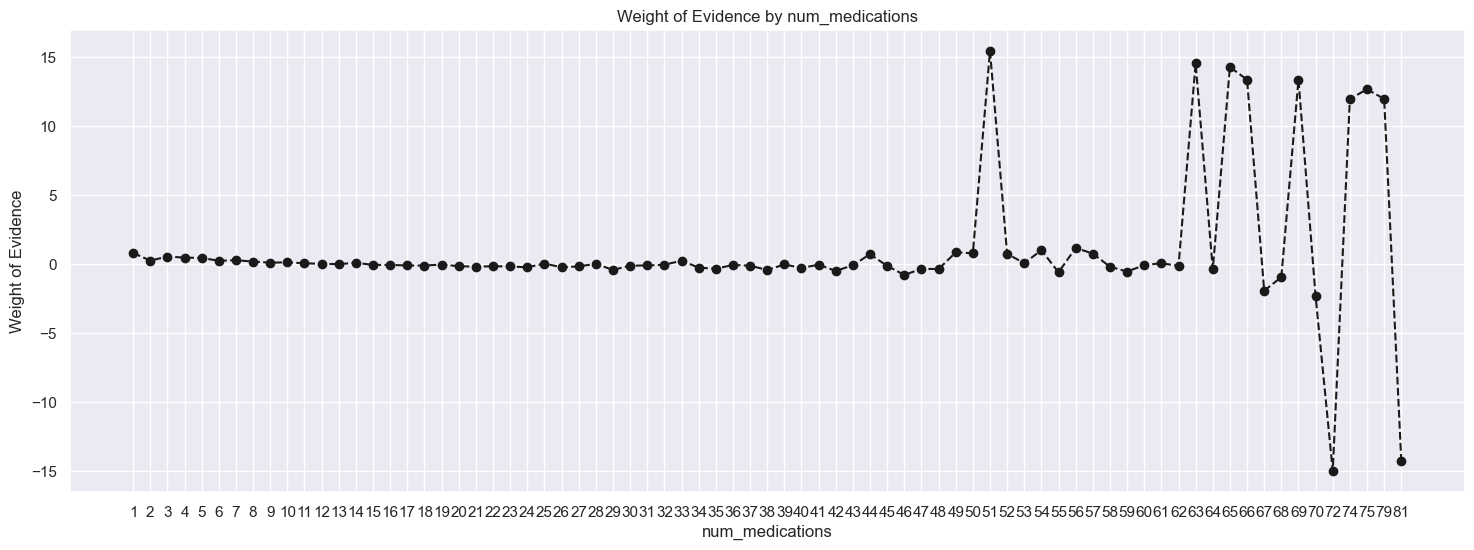

In [30]:
plot_by_woe(woe_discrete('num_medications'))

In [31]:
def bin_num_medications(x):
    if x <= 5:
        return '1-5'
    elif x <= 10:
        return '6-10'
    elif x <= 15:
        return '11-15'
    elif x <= 25:
        return '16-25'
    elif x <= 30:
        return '26-30'
    else:
        return '31+'

df['num_medications_coarse'] = df['num_medications'].apply(bin_num_medications)

In [32]:
woe_discrete('num_medications_coarse')

,num_medications_coarse,n_obs,prop_bad,prop_good,n_bad,n_good,prop_n_bad,prop_n_good,WoE,%Good - %Bad,IV,prop_total
0,1-5,4142,0.057702,0.942298,239.0,3903.0,0.037979,0.059842,0.454678,0.021863,0.02349,0.057918
1,11-15,20602,0.087030,0.912970,1793.0,18809.0,0.284920,0.288384,0.012086,0.003465,0.02349,0.288079
2,16-25,23311,0.098108,0.901892,2287.0,21024.0,0.363420,0.322345,-0.119935,-0.041074,0.02349,0.325960
3,26-30,4008,0.105040,0.894960,421.0,3587.0,0.066900,0.054997,-0.195920,-0.011903,0.02349,0.056044
4,31+,3736,0.097430,0.902570,364.0,3372.0,0.057842,0.051700,-0.112251,-0.006142,0.02349,0.052241
5,6-10,15716,0.075655,0.924345,1189.0,14527.0,0.188940,0.222732,0.164537,0.033792,0.02349,0.219758


In [33]:
woe_med = woe_discrete('num_medications_coarse')

order = ['1-5', '6-10', '11-15', '16-25', '26-30', '31+']

woe_med['num_medications_coarse'] = pd.Categorical(
    woe_med['num_medications_coarse'],
    categories=order,
    ordered=True
)

woe_med = woe_med.sort_values('num_medications_coarse')

In [34]:
woe_med 

,num_medications_coarse,n_obs,prop_bad,prop_good,n_bad,n_good,prop_n_bad,prop_n_good,WoE,%Good - %Bad,IV,prop_total
0,1-5,4142,0.057702,0.942298,239.0,3903.0,0.037979,0.059842,0.454678,0.021863,0.02349,0.057918
5,6-10,15716,0.075655,0.924345,1189.0,14527.0,0.188940,0.222732,0.164537,0.033792,0.02349,0.219758
1,11-15,20602,0.087030,0.912970,1793.0,18809.0,0.284920,0.288384,0.012086,0.003465,0.02349,0.288079
2,16-25,23311,0.098108,0.901892,2287.0,21024.0,0.363420,0.322345,-0.119935,-0.041074,0.02349,0.325960
3,26-30,4008,0.105040,0.894960,421.0,3587.0,0.066900,0.054997,-0.195920,-0.011903,0.02349,0.056044
4,31+,3736,0.097430,0.902570,364.0,3372.0,0.057842,0.051700,-0.112251,-0.006142,0.02349,0.052241


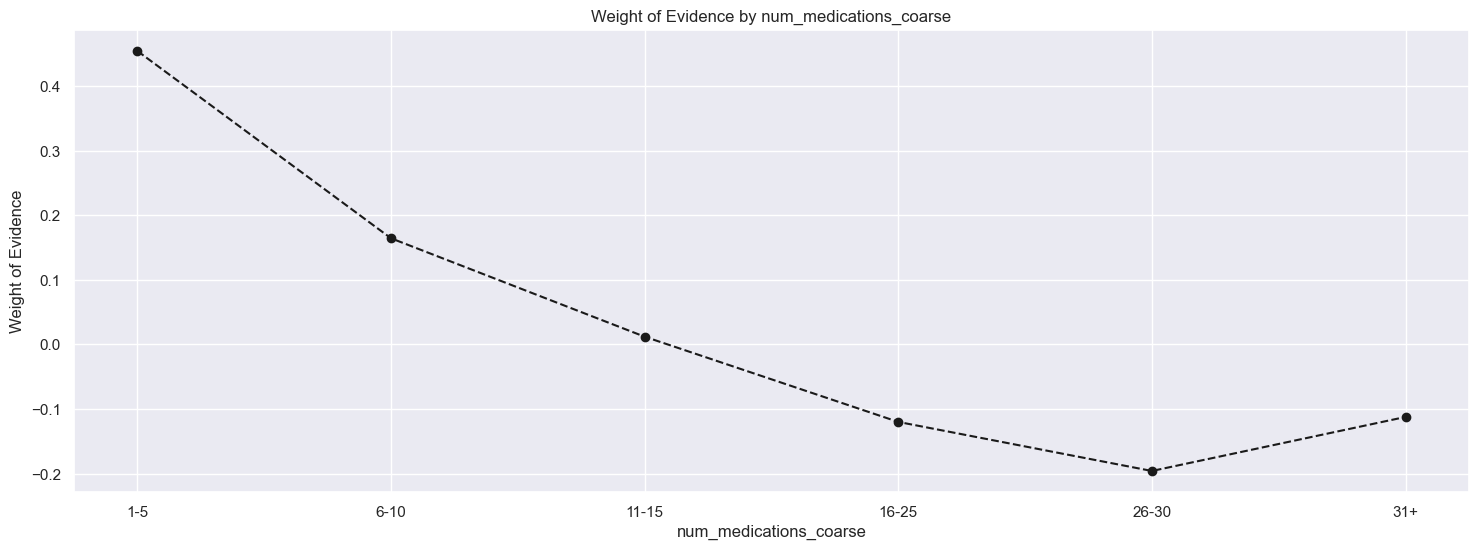

In [35]:
plot_by_woe(woe_med)  # dont force monotonicity, this may be really happening, highest meds under the most supervision.

### Time in Hospital

In [36]:
pd.set_option("display.max_rows", 15)

In [37]:
woe_discrete('time_in_hospital')

,time_in_hospital,n_obs,prop_bad,prop_good,n_bad,n_good,prop_n_bad,prop_n_good,WoE,%Good - %Bad,IV,prop_total
0,1,10715,0.064022,0.935978,686.0,10029.0,0.109010,0.153767,0.344000,0.044757,0.044976,0.149829
1,2,12397,0.075583,0.924417,937.0,11460.0,0.148896,0.175708,0.165576,0.026812,0.044976,0.173348
2,3,12701,0.080702,0.919298,1025.0,11676.0,0.162879,0.179019,0.094484,0.016140,0.044976,0.177599
3,4,9567,0.087384,0.912616,836.0,8731.0,0.132846,0.133866,0.007648,0.001020,0.044976,0.133776
4,5,6839,0.095774,0.904226,655.0,6184.0,0.104084,0.094815,-0.093274,-0.009269,0.044976,0.095630
5,6,5171,0.106556,0.893444,551.0,4620.0,0.087558,0.070835,-0.211944,-0.016723,0.044976,0.072307
6,7,3999,0.112028,0.887972,448.0,3551.0,0.071190,0.054445,-0.268168,-0.016745,0.044976,0.055918
7,8,2918,0.119945,0.880055,350.0,2568.0,0.055617,0.039373,-0.345409,-0.016244,0.044976,0.040803
8,9,1990,0.118593,0.881407,236.0,1754.0,0.037502,0.026893,-0.332537,-0.010609,0.044976,0.027826
9,10,1558,0.118742,0.881258,185.0,1373.0,0.029398,0.021051,-0.333961,-0.008347,0.044976,0.021786


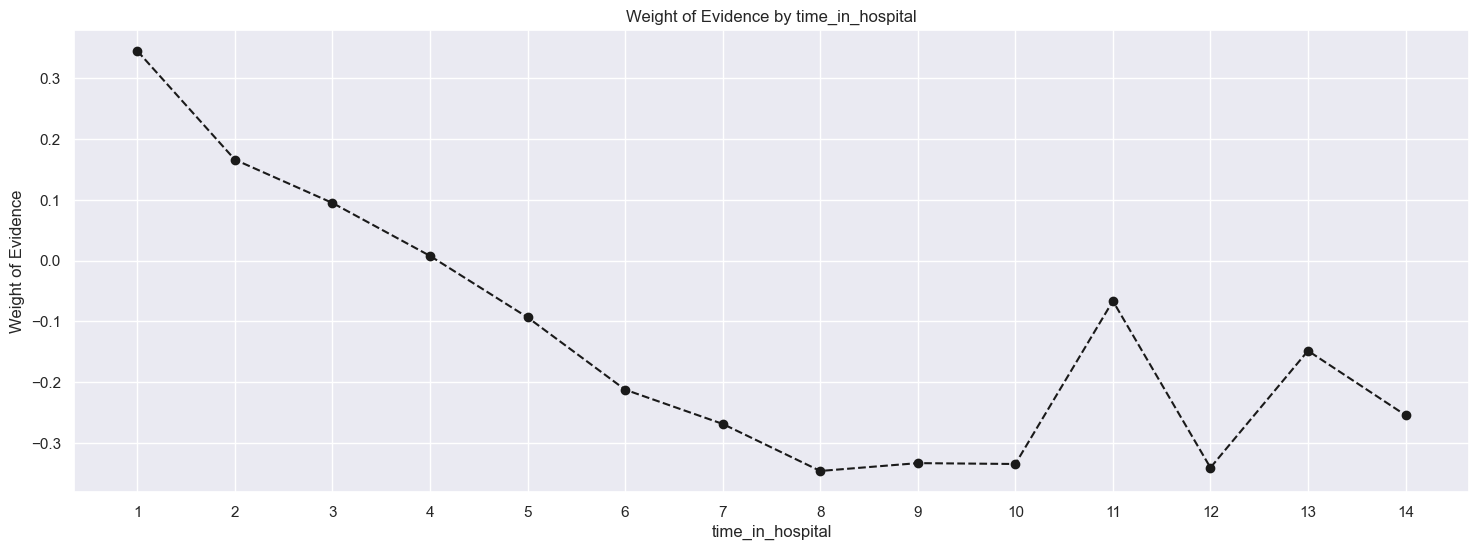

In [38]:
plot_by_woe(woe_discrete('time_in_hospital')) 

In [39]:
def bin_time_in_hospital(x):
    if x >= 8:
        return '8+'
    else:
        return str(x)

df['time_in_hospital_coarse'] = df['time_in_hospital'].apply(bin_time_in_hospital)

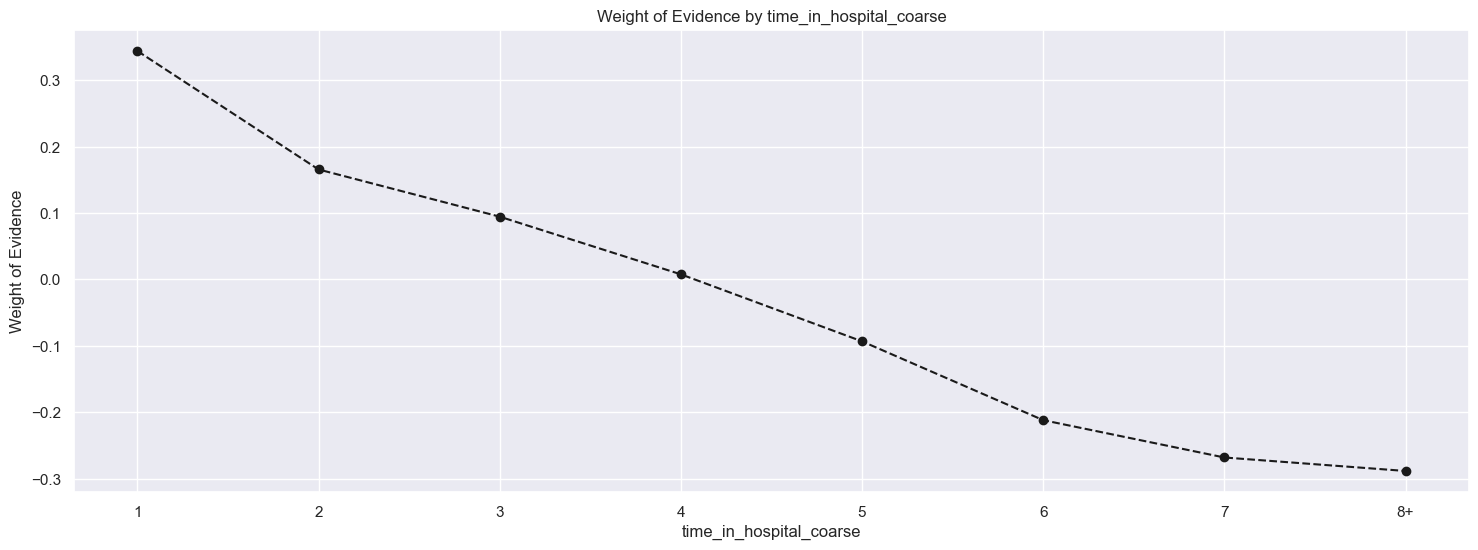

In [40]:
plot_by_woe(woe_discrete('time_in_hospital_coarse')) 

### num_lab_procedures

In [41]:
pd.set_option("display.max_rows", 20)

In [42]:
woe_discrete('num_lab_procedures')  # just use as it is...

,num_lab_procedures,n_obs,prop_bad,prop_good,n_bad,n_good,prop_n_bad,prop_n_good,WoE,%Good - %Bad,IV,prop_total
0,1,2285,0.062582,0.937418,143.0,2142.0,0.022724,0.032842,0.368292,0.010118,0.040104,0.031951
1,2,779,0.093710,0.906290,73.0,706.0,0.011600,0.010825,-0.069203,-0.000776,0.040104,0.010893
2,3,508,0.068898,0.931102,35.0,473.0,0.005562,0.007252,0.265388,0.001690,0.040104,0.007103
3,4,294,0.051020,0.948980,15.0,279.0,0.002384,0.004278,0.584803,0.001894,0.040104,0.004111
4,5,212,0.075472,0.924528,16.0,196.0,0.002543,0.003005,0.167167,0.000463,0.040104,0.002964
...,...,...,...,...,...,...,...,...,...,...,...,...
111,114,2,0.000000,1.000000,0.0,2.0,0.000000,0.000031,12.633449,0.000031,0.040104,0.000028
112,118,1,0.000000,1.000000,0.0,1.0,0.000000,0.000015,11.940305,0.000015,0.040104,0.000014
113,120,1,0.000000,1.000000,0.0,1.0,0.000000,0.000015,11.940305,0.000015,0.040104,0.000014
114,121,1,0.000000,1.000000,0.0,1.0,0.000000,0.000015,11.940305,0.000015,0.040104,0.000014


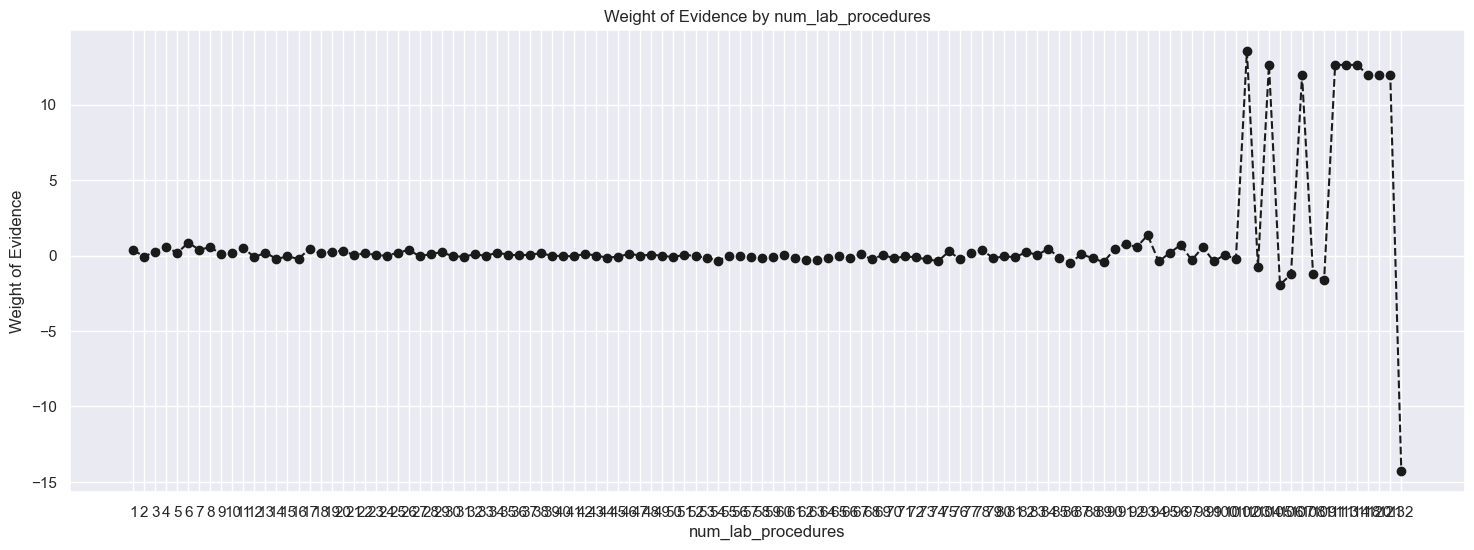

In [43]:
plot_by_woe(woe_discrete('num_lab_procedures')) 

### Number of Diagnoses

In [44]:
woe_discrete('number_diagnoses')

,number_diagnoses,n_obs,prop_bad,prop_good,n_bad,n_good,prop_n_bad,prop_n_good,WoE,%Good - %Bad,IV,prop_total
0,1,193,0.031088,0.968912,6.0,187.0,0.000953,0.002867,1.100990,0.001914,0.025996,0.002699
1,2,881,0.046538,0.953462,41.0,840.0,0.006515,0.012879,0.681471,0.006364,0.025996,0.012319
2,3,2364,0.059222,0.940778,140.0,2224.0,0.022247,0.034099,0.427061,0.011852,0.025996,0.033056
3,4,4463,0.067443,0.932557,301.0,4162.0,0.047831,0.063813,0.288282,0.015982,0.025996,0.062406
4,5,8940,0.076622,0.923378,685.0,8255.0,0.108851,0.126568,0.150797,0.017717,0.025996,0.125009
5,6,7691,0.084904,0.915096,653.0,7038.0,0.103766,0.107908,0.039143,0.004142,0.025996,0.107544
6,7,7609,0.084899,0.915101,646.0,6963.0,0.102654,0.106758,0.039207,0.004105,0.025996,0.106397
7,8,7560,0.095767,0.904233,724.0,6836.0,0.115048,0.104811,-0.093192,-0.010237,0.025996,0.105712
8,9,31739,0.097294,0.902706,3088.0,28651.0,0.490704,0.439284,-0.110694,-0.051420,0.025996,0.443809
9,10,9,0.111111,0.888889,1.0,8.0,0.000159,0.000123,-0.258917,-0.000036,0.025996,0.000126


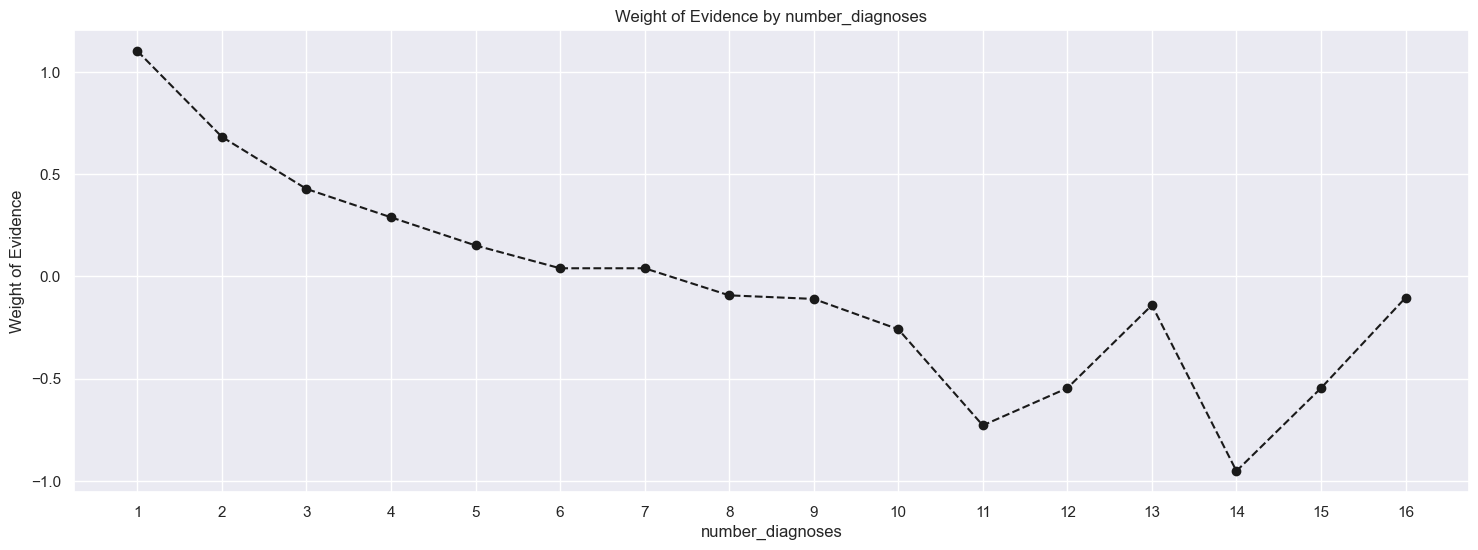

In [45]:
plot_by_woe(woe_discrete('number_diagnoses'))

In [46]:
def bin_number_diagnoses(x):
    if 6 <= x <= 7:
        return "6-7"
    
    elif x >= 9:
        return '9+'
    else:
        return str(x)

df['number_diagnoses_coarse'] = df['number_diagnoses'].apply(bin_number_diagnoses)

In [47]:
woe_discrete('number_diagnoses_coarse')

,number_diagnoses_coarse,n_obs,prop_bad,prop_good,n_bad,n_good,prop_n_bad,prop_n_good,WoE,%Good - %Bad,IV,prop_total
0,1,193,0.031088,0.968912,6.0,187.0,0.000953,0.002867,1.100990,0.001914,0.025831,0.002699
1,2,881,0.046538,0.953462,41.0,840.0,0.006515,0.012879,0.681471,0.006364,0.025831,0.012319
2,3,2364,0.059222,0.940778,140.0,2224.0,0.022247,0.034099,0.427061,0.011852,0.025831,0.033056
3,4,4463,0.067443,0.932557,301.0,4162.0,0.047831,0.063813,0.288282,0.015982,0.025831,0.062406
4,5,8940,0.076622,0.923378,685.0,8255.0,0.108851,0.126568,0.150797,0.017717,0.025831,0.125009
5,6-7,15300,0.084902,0.915098,1299.0,14001.0,0.206420,0.214667,0.039175,0.008247,0.025831,0.213941
6,8,7560,0.095767,0.904233,724.0,6836.0,0.115048,0.104811,-0.093192,-0.010237,0.025831,0.105712
7,9+,31814,0.097347,0.902653,3097.0,28717.0,0.492134,0.440296,-0.111304,-0.051838,0.025831,0.444858


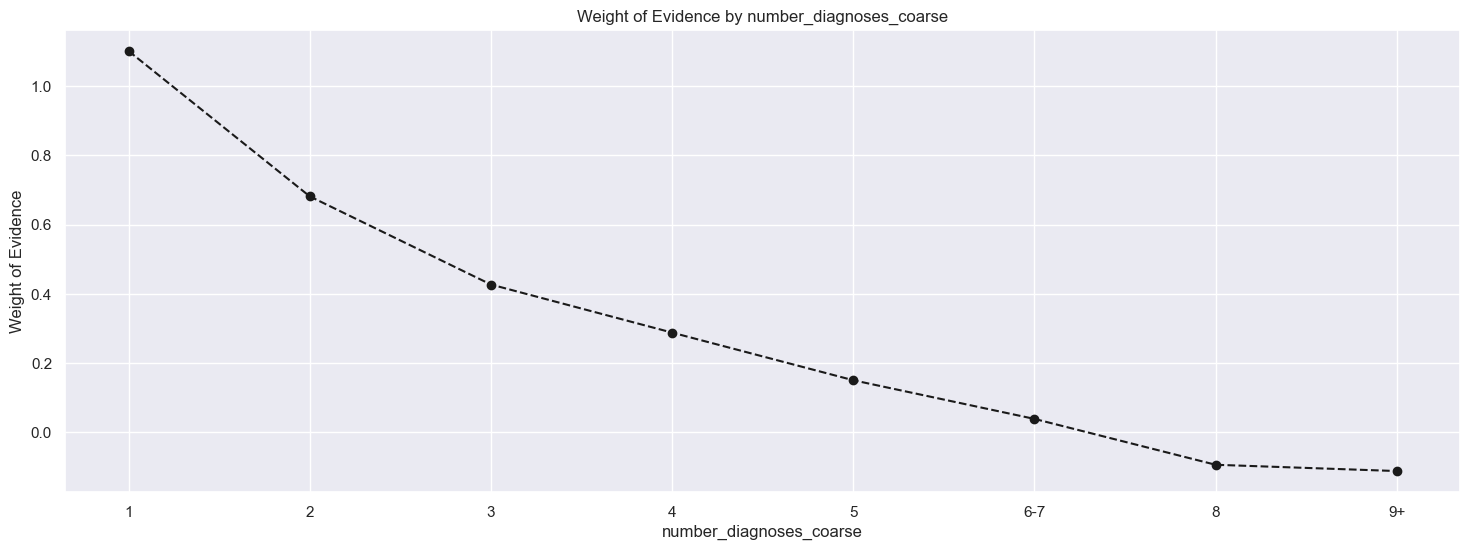

In [48]:
plot_by_woe(woe_discrete('number_diagnoses_coarse'))

### Number of Emergency

In [49]:
woe_discrete('number_emergency')

,number_emergency,n_obs,prop_bad,prop_good,n_bad,n_good,prop_n_bad,prop_n_good,WoE,%Good - %Bad,IV,prop_total
0,0,66311,0.085627,0.914373,5678.0,60633.0,0.902272,0.929640,0.029881,0.027368,0.020244,0.927232
1,1,3965,0.110467,0.889533,438.0,3527.0,0.069601,0.054077,-0.252375,-0.015524,0.020244,0.055443
2,2,804,0.133085,0.866915,107.0,697.0,0.017003,0.010687,-0.464402,-0.006316,0.020244,0.011242
3,3,246,0.126016,0.873984,31.0,215.0,0.004926,0.003296,-0.401708,-0.001630,0.020244,0.003440
4,4,96,0.239583,0.760417,23.0,73.0,0.003655,0.001119,-1.183394,-0.002536,0.020244,0.001342
5,5,33,0.151515,0.848485,5.0,28.0,0.000795,0.000429,-0.615592,-0.000365,0.020244,0.000461
6,6,26,0.230769,0.769231,6.0,20.0,0.000953,0.000307,-1.134386,-0.000647,0.020244,0.000364
7,7,8,0.125000,0.875000,1.0,7.0,0.000159,0.000107,-0.392448,-0.000052,0.020244,0.000112
8,8,9,0.222222,0.777778,2.0,7.0,0.000318,0.000107,-1.085595,-0.000210,0.020244,0.000126
9,9,4,0.000000,1.000000,0.0,4.0,0.000000,0.000061,13.326595,0.000061,0.020244,0.000056


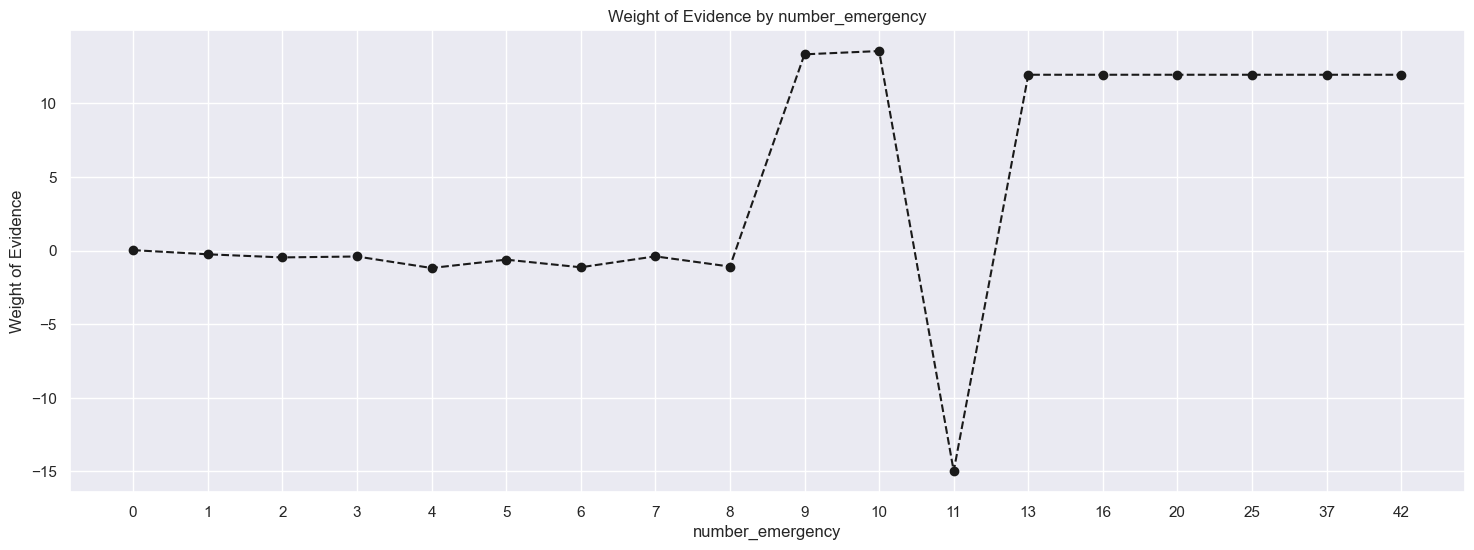

In [50]:
plot_by_woe(woe_discrete('number_emergency'))

In [51]:
def bin_number_emergency(x):
    if x >= 2:
        return "2+"
    else:
        return str(x)

df['number_emergency_coarse'] = df['number_emergency'].apply(bin_number_emergency)

In [52]:
woe_discrete('number_emergency_coarse')

,number_emergency_coarse,n_obs,prop_bad,prop_good,n_bad,n_good,prop_n_bad,prop_n_good,WoE,%Good - %Bad,IV,prop_total
0,0,66311,0.085627,0.914373,5678.0,60633.0,0.902272,0.929640,0.029881,0.027368,0.011209,0.927232
1,1,3965,0.110467,0.889533,438.0,3527.0,0.069601,0.054077,-0.252375,-0.015524,0.011209,0.055443
2,2+,1239,0.142857,0.857143,177.0,1062.0,0.028126,0.016283,-0.546599,-0.011844,0.011209,0.017325


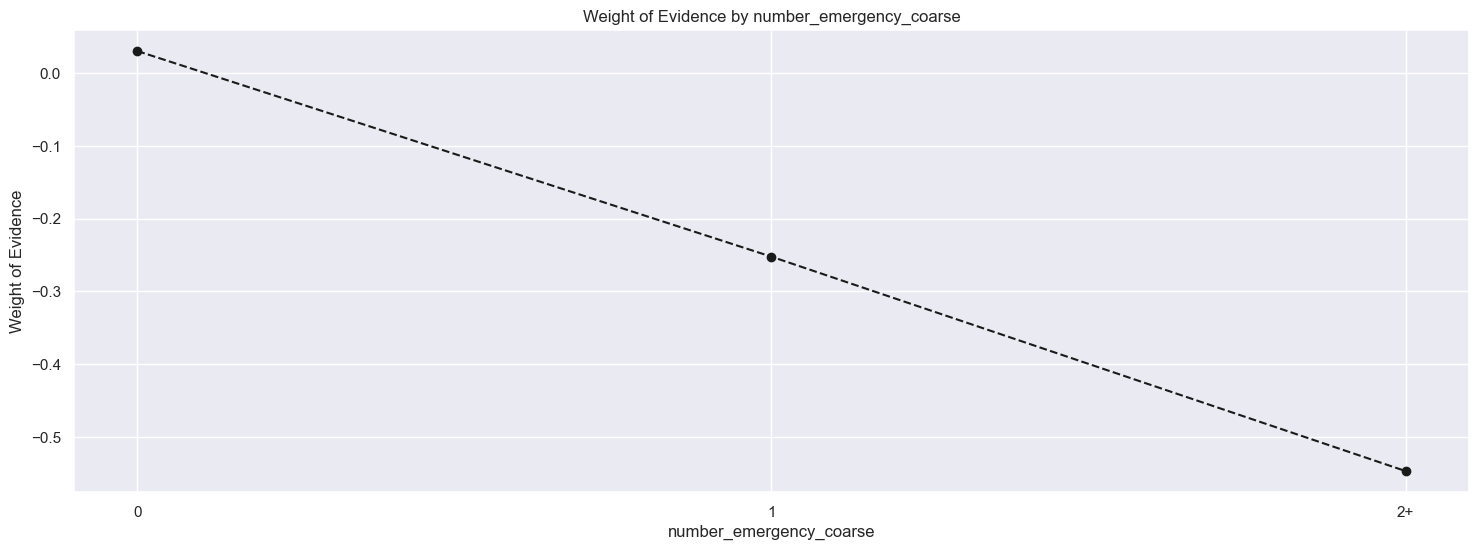

In [53]:
plot_by_woe(woe_discrete('number_emergency_coarse'))

### Number of Outpatients

In [54]:
woe_discrete('number_outpatient')

,number_outpatient,n_obs,prop_bad,prop_good,n_bad,n_good,prop_n_bad,prop_n_good,WoE,%Good - %Bad,IV,prop_total
0,0,62209,0.086193,0.913807,5362.0,56847.0,0.852058,0.871592,0.022667,0.019535,0.016829,0.869873
1,1,4867,0.102116,0.897884,497.0,4370.0,0.078977,0.067002,-0.164431,-0.011975,0.016829,0.068056
2,2,2025,0.100741,0.899259,204.0,1821.0,0.032417,0.027920,-0.149338,-0.004497,0.016829,0.028316
3,3,1116,0.085125,0.914875,95.0,1021.0,0.015096,0.015654,0.036302,0.000558,0.016829,0.015605
4,4,585,0.112821,0.887179,66.0,519.0,0.010488,0.007957,-0.276110,-0.002530,0.016829,0.008180
...,...,...,...,...,...,...,...,...,...,...,...,...
28,29,1,0.000000,1.000000,0.0,1.0,0.000000,0.000015,11.940305,0.000015,0.016829,0.000014
29,33,2,0.000000,1.000000,0.0,2.0,0.000000,0.000031,12.633449,0.000031,0.016829,0.000028
30,35,1,0.000000,1.000000,0.0,1.0,0.000000,0.000015,11.940305,0.000015,0.016829,0.000014
31,36,1,0.000000,1.000000,0.0,1.0,0.000000,0.000015,11.940305,0.000015,0.016829,0.000014


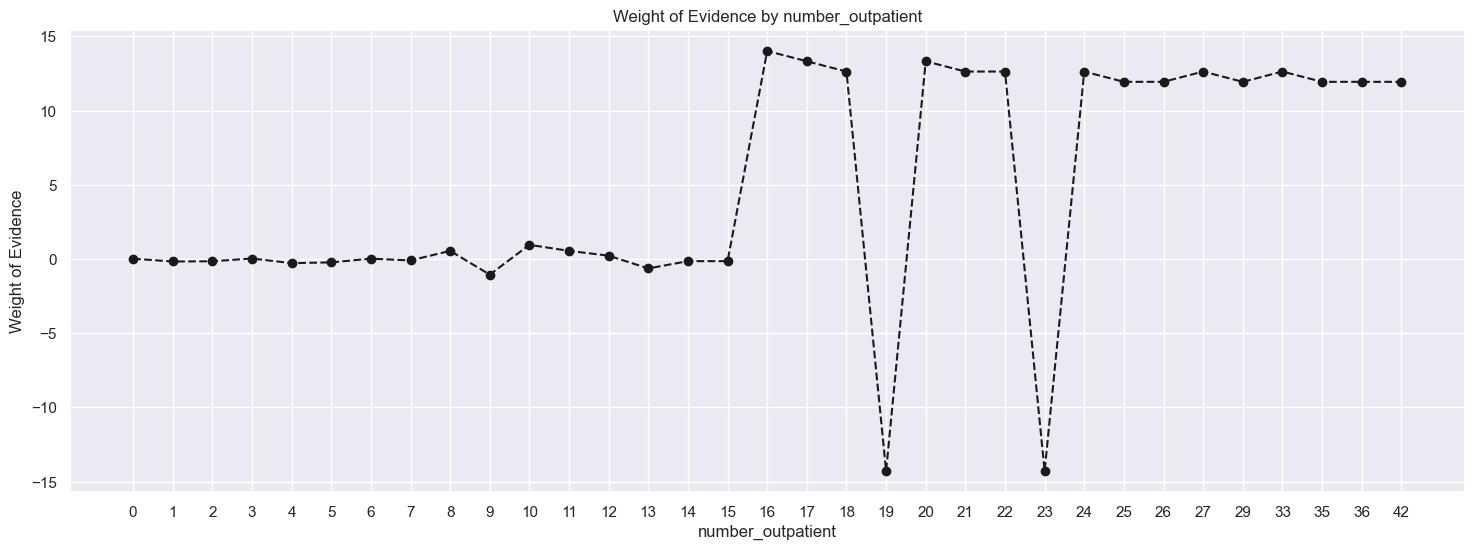

In [55]:
plot_by_woe(woe_discrete('number_outpatient'))

In [56]:
def bin_number_outpatient(x):
    if x == 0:
        return '0'
    elif x <= 4:
        return '1-4'
    else:
        return '5+'

df['number_outpatient_coarse'] = df['number_outpatient'].apply(bin_number_outpatient)

In [57]:
woe_discrete('number_outpatient_coarse')

,number_outpatient_coarse,n_obs,prop_bad,prop_good,n_bad,n_good,prop_n_bad,prop_n_good,WoE,%Good - %Bad,IV,prop_total
0,0,62209,0.086193,0.913807,5362.0,56847.0,0.852058,0.871592,0.022667,0.019535,0.003224,0.869873
1,1-4,8593,0.100314,0.899686,862.0,7731.0,0.136978,0.118534,-0.144621,-0.018444,0.003224,0.120157
2,5+,713,0.096774,0.903226,69.0,644.0,0.010965,0.009874,-0.104767,-0.001091,0.003224,0.009970


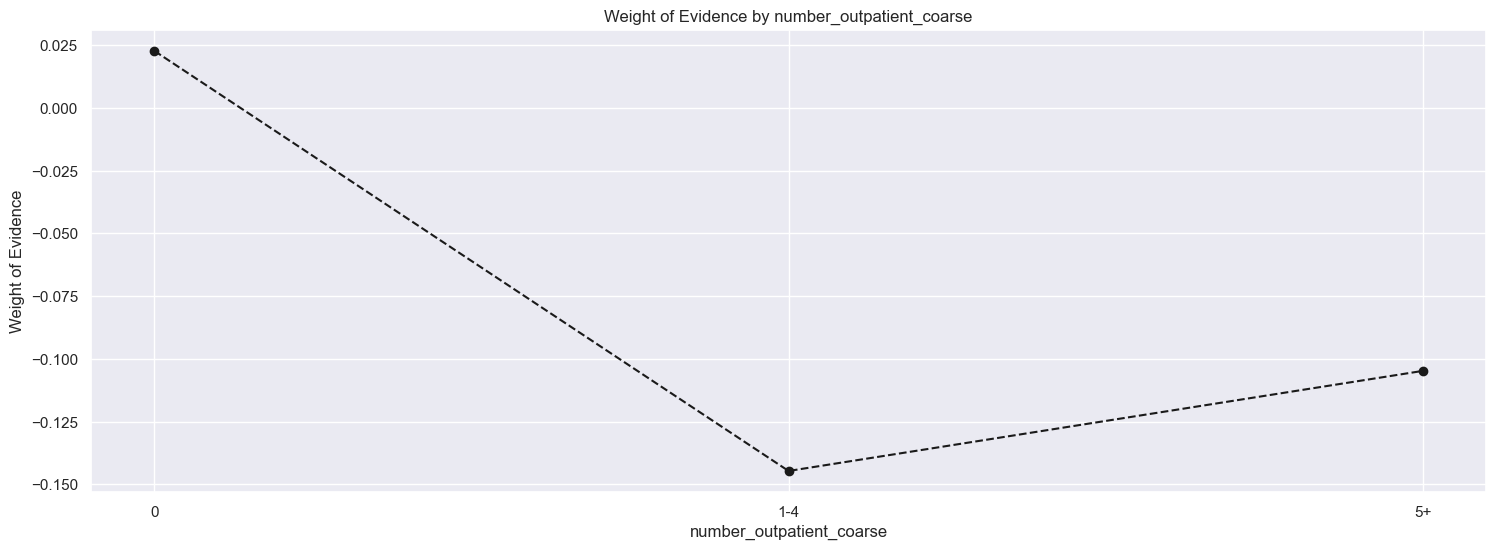

In [58]:
plot_by_woe(woe_discrete('number_outpatient_coarse'))

#### end

In [59]:
woe_out = woe_discrete('age_coarse')
woe_map = dict(zip(woe_out['age_coarse'], woe_out['WoE']))

df['age_coarse_WoE'] = df['age_coarse'].map(woe_map)

In [60]:
woe_out = woe_discrete('number_inpatient_coarse')
woe_map = dict(zip(woe_out['number_inpatient_coarse'], woe_out['WoE']))

df['number_inpatient_WoE'] = df['number_inpatient_coarse'].map(woe_map)

In [61]:
woe_out = woe_discrete('number_diagnoses_coarse')
woe_map = dict(zip(woe_out['number_diagnoses_coarse'], woe_out['WoE']))

df['number_diagnoses_WoE'] = df['number_diagnoses_coarse'].map(woe_map)

In [62]:
woe_out = woe_discrete('number_emergency_coarse')
woe_map = dict(zip(woe_out['number_emergency_coarse'], woe_out['WoE']))

df['number_emergency_WoE'] = df['number_emergency_coarse'].map(woe_map)

In [63]:
woe_out = woe_discrete('num_medications_coarse')
woe_map = dict(zip(woe_out['num_medications_coarse'], woe_out['WoE']))

df['num_medications_WoE'] = df['num_medications_coarse'].map(woe_map)

In [64]:
woe_out = woe_discrete('number_outpatient_coarse')
woe_map = dict(zip(woe_out['number_outpatient_coarse'], woe_out['WoE']))

df['number_outpatient_WoE'] = df['number_outpatient_coarse'].map(woe_map)

In [65]:
woe_out = woe_discrete('time_in_hospital_coarse')
woe_map = dict(zip(woe_out['time_in_hospital_coarse'], woe_out['WoE']))

df['time_in_hospital_WoE'] = df['time_in_hospital_coarse'].map(woe_map)

In [88]:
final_final_factors = ['age_coarse_WoE', # keep original binning
                'number_inpatient_WoE',
                'num_medications_WoE',
                'time_in_hospital_WoE',
                # 'num_lab_procedures',     
                'number_diagnoses_WoE', 
                'number_emergency_WoE'
                ]

In [89]:
X = df[final_final_factors]
y = df['readmitted_binary']

In [90]:
X

,age_coarse_WoE,number_inpatient_WoE,num_medications_WoE,time_in_hospital_WoE,number_diagnoses_WoE,number_emergency_WoE
8,-0.149275,0.108503,-0.195920,-0.288462,-0.093192,0.029881
9,-0.149275,0.108503,-0.119935,-0.288462,-0.093192,0.029881
4,0.192642,0.108503,0.164537,0.344000,0.150797,0.029881
10,0.192642,0.108503,-0.119935,-0.288462,-0.111304,0.029881
5,0.240495,0.108503,-0.119935,0.094484,-0.111304,0.029881
...,...,...,...,...,...,...
101754,-0.149275,0.108503,-0.112251,-0.288462,-0.111304,0.029881
101755,0.192642,0.108503,-0.195920,-0.288462,-0.111304,-0.252375
101756,-0.007534,-0.396659,-0.119935,0.165576,-0.111304,-0.252375
101758,-0.149275,0.108503,-0.119935,-0.093274,-0.111304,-0.252375


In [91]:
import seaborn as sns

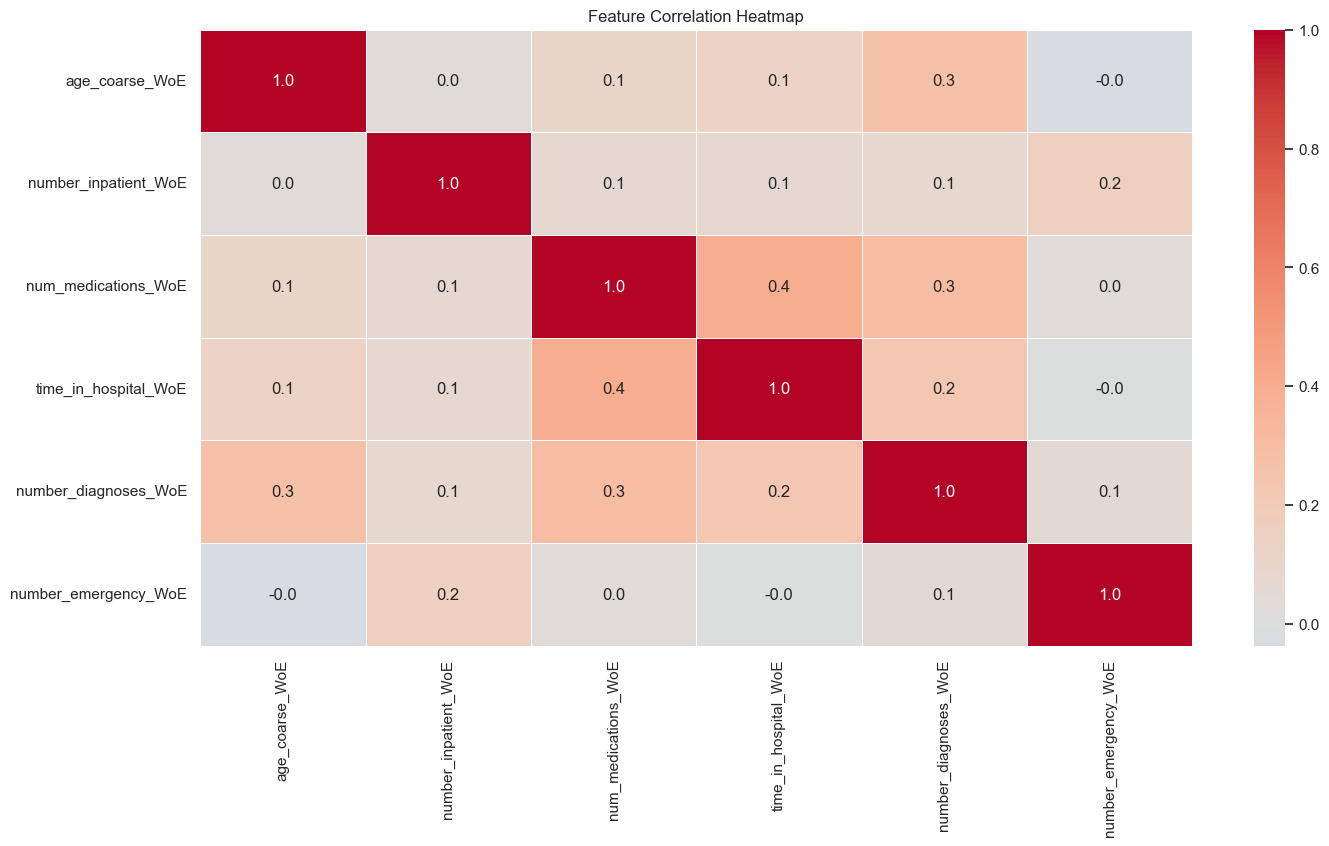

In [92]:
corr_matrix = X.corr()

plt.figure(figsize=(16,8))
sns.heatmap(corr_matrix, 
            cmap='coolwarm', 
            center=0, 
            annot=True,          
            fmt=".1f",           
            linewidths=0.5)      
plt.title("Feature Correlation Heatmap")
plt.show()

In [127]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [128]:
# Flip sign of all WoE variables so higher WoE = higher risk
for col in X_train.columns:
    if col.endswith('_WoE'):
        X_train[col] = -X_train[col]
        X_test[col]  = -X_test[col]

In [129]:
import statsmodels.api as sm

X_train_const = sm.add_constant(X_train)
X_test_const  = sm.add_constant(X_test)

logit_model = sm.Logit(y_train, X_train_const)
result = logit_model.fit(disp=False)

In [130]:
print(result.summary())

                           Logit Regression Results                           
Dep. Variable:      readmitted_binary   No. Observations:                50060
Model:                          Logit   Df Residuals:                    50053
Method:                           MLE   Df Model:                            6
Date:                Mon, 13 Oct 2025   Pseudo R-squ.:                 0.02038
Time:                        23:55:32   Log-Likelihood:                -14608.
converged:                       True   LL-Null:                       -14912.
Covariance Type:            nonrobust   LLR p-value:                4.563e-128
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -2.3390      0.016   -145.723      0.000      -2.370      -2.308
age_coarse_WoE           0.7158      0.098      7.308      0.000       0.524       0.908
number_inpat

In [131]:
y_pred_prob = result.predict(X_test_const)

In [132]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

print("AUC:", roc_auc_score(y_test, y_pred_prob))

AUC: 0.6107702495250997
